In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
# Load scaled data (used for clustering)
df_scaled = pd.read_csv("../Data/Preprocessed/Preprocessed.csv")
print("Scaled data shape:", df_scaled.shape)

# Load original data (to keep raw feature values for interpretation)
import openpyxl
df_original = pd.read_excel("../Data/Raw/telecom_customer_segmentation.xlsx", engine='openpyxl')
print("Original data shape:", df_original.shape)

Scaled data shape: (5000, 21)
Original data shape: (5000, 20)


In [3]:
# Initialize and fit KMeans
kmeans = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
df_original['cluster'] = kmeans.fit_predict(df_scaled)

print("Cluster assignment completed.")
print(df_original['cluster'].value_counts().sort_index())

Cluster assignment completed.
cluster
0     404
1    1050
2    1291
3     497
4    1758
Name: count, dtype: int64


In [4]:
summary = df_original.groupby('cluster').agg(
    Count=('cluster', 'count'),
    Avg_Revenue=('monthly_revenue_usd', 'mean'),
    Avg_Call_Mins=('total_call_minutes', 'mean'),
    Avg_Data_GB=('data_usage_gb', 'mean'),
    Avg_Tenure=('tenure_months', 'mean'),
    Avg_Support_Tickets=('support_tickets_6mo', 'mean'),
    Avg_Logins=('logins_per_month', 'mean')
).round(2)

print("\n--- Cluster Summary (average values) ---")
print(summary)


--- Cluster Summary (average values) ---
         Count  Avg_Revenue  Avg_Call_Mins  Avg_Data_GB  Avg_Tenure  \
cluster                                                               
0          404        32.99         148.48         4.93        9.11   
1         1050        91.12         805.16        24.60       70.73   
2         1291        20.53          87.23         2.14       11.81   
3          497       212.97         590.16        19.65       88.39   
4         1758        44.33         344.66         9.90       35.38   

         Avg_Support_Tickets  Avg_Logins  
cluster                                   
0                       4.96        3.92  
1                       1.04       24.69  
2                       0.09        4.88  
3                       1.48       22.02  
4                       0.49       14.34  


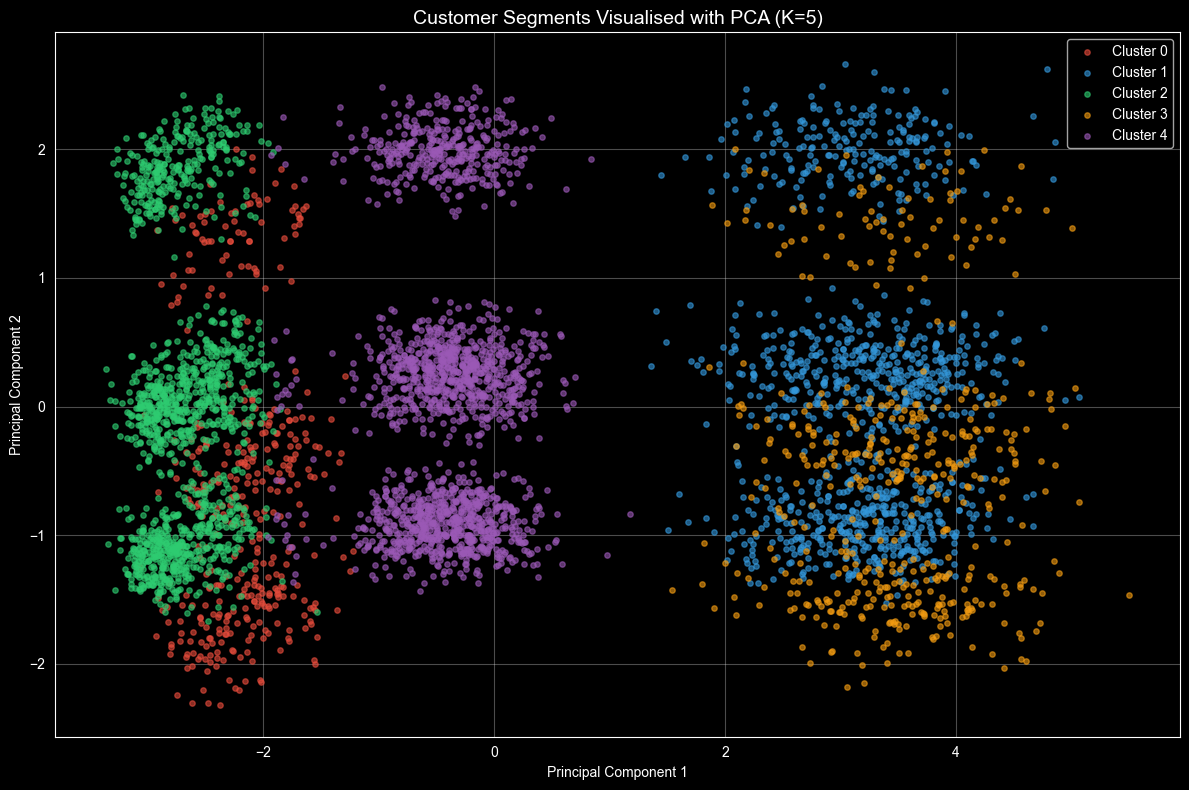

In [5]:
# Perform PCA
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(df_scaled)

# Plot each cluster with a different colour
plt.figure(figsize=(12, 8))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
for i in range(5):
    mask = df_original['cluster'] == i
    plt.scatter(coords[mask, 0], coords[mask, 1],
                c=colors[i], label=f'Cluster {i}', alpha=0.6, s=15)

plt.title('Customer Segments Visualised with PCA (K=5)', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()